In [ ]:
# Calculate Retail LGD using PD from retail PD model
import pandas as pd
# Load the predicted PD from retail model and loan data
retail_pd = pd.read_csv("./output/Fed_DR.csv")  
loan_data = pd.read_csv('./output/Fed_AvgLoan.csv')

# Merge PD with loan data
retail_lgd_df = pd.merge(retail_pd[['Quarter_dt', 'Retail_Proxy_DR']], 
                         loan_data[['Quarter_dt', 'Retail_Proxy_AvgLoan']], 
                         left_on='Quarter_dt', right_on='Quarter_dt', how='inner')

# Calculate Retail LGD: 0.9 * PD * Loan Balance
retail_lgd_df['Retail_LGD'] = 0.9 * retail_lgd_df['Retail_Proxy_DR'] * retail_lgd_df['Retail_Proxy_AvgLoan']
retail_lgd_df['Retail_LGD_pc'] = 0.9 * retail_lgd_df['Retail_Proxy_DR']
# Display results
print(retail_lgd_df)

# Save to file
retail_lgd_df.to_csv('./output/retail_lgd_calculated.csv', index=False)

     Quarter_dt  Retail_Proxy_DR  Retail_Proxy_AvgLoan   Retail_LGD  \
0    2000-01-01           0.0436                161806   6349.26744   
1    2000-04-01           0.0449                172818   6983.57538   
2    2000-07-01           0.0450                183728   7440.98400   
3    2000-10-01           0.0448                196106   7906.99392   
4    2001-01-01           0.0467                172441   7247.69523   
..          ...              ...                   ...          ...   
98   2024-07-01           0.0308                970202  26893.99944   
99   2024-10-01           0.0297                989734  26455.58982   
100  2025-01-01           0.0293                986158  26004.98646   
101  2025-04-01           0.0292                988251  25971.23628   
102  2025-07-01           0.0287               1004316  25941.48228   

     Retail_LGD_pc  
0          0.03924  
1          0.04041  
2          0.04050  
3          0.04032  
4          0.04203  
..             ...  


In [32]:
CO = pd.read_csv('output/Fed_CO.csv')
retail_lgd_df['Retail_NCO'] = CO['Retail_Proxy_NCO']

# compute the product with the avg‑loan
retail_lgd_df['Retail_NCO_times_AvgLoan'] = (
    retail_lgd_df['Retail_NCO'] * retail_lgd_df['Retail_Proxy_AvgLoan']
)

# inspect the results
retail_lgd_df['LGD_to_NCO_ratio'] = (
    retail_lgd_df['Retail_LGD'] / retail_lgd_df['Retail_NCO_times_AvgLoan']
)
retail_lgd_df['Quarter_dt'] = pd.to_datetime(retail_lgd_df['Quarter_dt'])
retail_lgd_df.set_index('Quarter_dt', inplace=True)
retail_lgd_df.index = retail_lgd_df.index.to_period('Q')
retail_lgd_df.head()

,Retail_Proxy_DR,Retail_Proxy_AvgLoan,Retail_LGD,Retail_LGD_pc,Retail_NCO,Retail_NCO_times_AvgLoan,LGD_to_NCO_ratio
Quarter_dt,,,,,,,
2000Q1,0.0436,161806,6349.26744,0.03924,0.0411,6650.2266,0.954745
2000Q2,0.0449,172818,6983.57538,0.04041,0.0378,6532.5204,1.069048
2000Q3,0.0450,183728,7440.98400,0.04050,0.0386,7091.9008,1.049223
2000Q4,0.0448,196106,7906.99392,0.04032,0.0406,7961.9036,0.993103
2001Q1,0.0467,172441,7247.69523,0.04203,0.0437,7535.6717,0.961785


In [41]:
from scipy import stats

# difference between the two columns
diff = retail_lgd_df['Retail_NCO_times_AvgLoan'] - retail_lgd_df['Retail_LGD']
retail_lgd_df['diff_NCO_vs_LGD'] = diff

print(diff.describe())

# paired t‑test
tstat, pval = stats.ttest_rel(retail_lgd_df['Retail_NCO_times_AvgLoan'],
                              retail_lgd_df['Retail_LGD']*10/9)
print(f"paired t‑statistic: {tstat:.3f}, p‑value: {pval:.3e}")

if pval < 0.05:
    print("The means are significantly different (p < 0.05).")
else:
    print("No statistically significant difference detected.")

# simple regression analysis: LGD on NCO * AvgLoan
X = retail_lgd_df['Retail_LGD_pc']
y = retail_lgd_df['Retail_NCO']
X = sm.add_constant(X)                # add intercept
model = sm.OLS(y, X).fit()
print(model.summary())

count      103.000000
mean      7660.370578
std       7064.733336
min       -822.678960
25%       2825.185840
50%       6590.369520
75%      10017.360200
max      37825.862750
dtype: float64
paired t‑statistic: 9.424, p‑value: 1.536e-15
The means are significantly different (p < 0.05).
                            OLS Regression Results                            
Dep. Variable:             Retail_NCO   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     211.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.72e-26
Time:                        00:50:18   Log-Likelihood:                 321.51
No. Observations:                 103   AIC:                            -639.0
Df Residuals:                     101   BIC:                            -633.8
Df Model:                           1                                         
Co

In [26]:
macro_path = './output/ccar_macro_data_quarterly.csv'
df_macro = pd.read_csv(macro_path)
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'])
df_macro.set_index('DATE', inplace=True)
df_macro.index = df_macro.index.to_period('Q')
print(df_macro.describe())
df_macro

       Unemployment_Rate      Real_GDP  BBB_Spread  VIX_Volatility_Index  \
count         104.000000    104.000000  104.000000            104.000000   
mean            5.640545  18273.150202    1.980944             19.834158   
std             1.936582   2847.680659    0.997186              7.394865   
min             3.533333  13878.147000    0.994030             10.307937   
25%             4.166667  16319.276250    1.321654             14.466469   
50%             5.016667  17576.126000    1.751620             17.872615   
75%             6.208333  20463.450500    2.280861             24.013756   
max            13.000000  24111.830000    7.030462             58.604687   

       10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  CPI_Inflation  \
count          104.000000        104.000000  104.000000     104.000000   
mean             3.322854          1.889647    5.102782     233.471003   
std              1.285874          1.933953    2.012014      41.567073   
min              0.

,Unemployment_Rate,Real_GDP,BBB_Spread,VIX_Volatility_Index,10Y_Treasury_Yield,3M_Treasury_Rate,Prime_Rate,CPI_Inflation,Real_Disposable_Income,Nominal_GDP,Corporate_Profits,House_Price_Index,Stock_Market_Index,Real_GDP_Growth,Nominal_GDP_Growth,Corp_Profits_YoY,HPI_YoY,Stock_Market_Return
DATE,,,,,,,,,,,,,,,,,,
2000Q1,4.033333,13878.147,1.609077,23.150317,6.468413,5.520000,8.694444,170.100000,9833.933333,10002.179,565.043,100.679000,4427.873492,0.014512,0.041215,0.022773,0.081380,0.354351
2000Q2,3.933333,14130.908,2.139231,24.923968,6.184921,5.713333,9.250000,171.433333,9950.166667,10247.720,559.322,103.699000,3747.218571,0.072852,0.098195,-0.016277,0.087128,-0.153720
2000Q3,4.000000,14145.312,2.151515,19.169048,5.889841,6.016667,9.500000,173.000000,10081.500000,10318.165,554.170,106.461000,3933.188413,0.004077,0.027497,-0.026534,0.088221,0.049629
2000Q4,3.900000,14229.765,2.496923,26.016667,5.570645,6.016667,9.500000,174.233333,10149.000000,10435.744,533.362,108.271333,3026.412857,0.023882,0.045581,-0.097514,0.091724,-0.230545
2001Q1,4.233333,14183.120,2.422154,25.726452,5.044194,4.816667,8.620968,175.900000,10229.833333,10470.231,562.885,109.750667,2355.525161,-0.013112,0.013219,-0.003819,0.090105,-0.221678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024Q4,4.133333,23586.542,1.032121,17.363231,4.275484,4.400000,7.823077,316.587667,17843.266667,29825.182,3689.460,323.695667,18983.195312,0.018395,0.042494,0.099872,0.037609,0.077941
2025Q1,4.133333,23548.210,1.060000,18.521111,4.453607,4.210000,7.500000,319.475000,17943.133333,30042.113,3335.780,325.511000,18951.462833,-0.006501,0.029094,-0.016894,0.038446,-0.001672
2025Q2,4.200000,23770.976,1.231231,23.561406,4.361774,4.230000,7.500000,320.785667,18025.300000,30485.729,3355.897,330.980000,18309.732097,0.037840,0.059066,-0.032526,0.023799,-0.033862


In [50]:
df_model = retail_lgd_df[['Retail_LGD_pc']].join(df_macro, how='inner')
df_model = df_model.drop(['VIX_Volatility_Index', 'BBB_Spread','Prime_Rate','Nominal_GDP','Corporate_Profits','Stock_Market_Index','Nominal_GDP_Growth','Corp_Profits_YoY','House_Price_Index','Stock_Market_Return','Real_GDP'], axis=1)
df_model ['CPI_Inflation_QoQ'] = df_model['CPI_Inflation'].pct_change()*4
df_model = df_model.drop('CPI_Inflation', axis=1)
df_model = df_model.dropna()
print(df_model.head())

        Retail_LGD_pc  Unemployment_Rate  10Y_Treasury_Yield  \
2000Q2        0.04041           3.933333            6.184921   
2000Q3        0.04050           4.000000            5.889841   
2000Q4        0.04032           3.900000            5.570645   
2001Q1        0.04203           4.233333            5.044194   
2001Q2        0.04266           4.400000            5.276190   

        3M_Treasury_Rate  Real_Disposable_Income  Real_GDP_Growth   HPI_YoY  \
2000Q2          5.713333             9950.166667         0.072852  0.087128   
2000Q3          6.016667            10081.500000         0.004077  0.088221   
2000Q4          6.016667            10149.000000         0.023882  0.091724   
2001Q1          4.816667            10229.833333        -0.013112  0.090105   
2001Q2          3.660000            10221.966667         0.024980  0.082367   

        CPI_Inflation_QoQ  
2000Q2           0.031354  
2000Q3           0.036555  
2000Q4           0.028516  
2001Q1           0.038263  


In [51]:
candidate_macros = df_macro.columns.tolist()
lags_to_test = [1, 2, 3, 4]
for lag in lags_to_test:
    df_model[f'LGD_Lag{lag}'] = df_model['Retail_LGD_pc'].shift(lag)

for macro in candidate_macros:
    if macro in df_model.columns:  
        for lag in lags_to_test:
            col_name = f'{macro}_Lag{lag}'
            df_model[col_name] = df_model[macro].shift(lag)

df_model.dropna(inplace=True)
df_model.to_csv('./output/retail_lgd_model_candidates.csv')

In [48]:
df_model

,Retail_LGD_pc,Unemployment_Rate,10Y_Treasury_Yield,3M_Treasury_Rate,Real_Disposable_Income,Real_GDP_Growth,HPI_YoY,CPI_Inflation_QoQ,LGD_Lag1,LGD_Lag2,...,Real_Disposable_Income_Lag3,Real_Disposable_Income_Lag4,Real_GDP_Growth_Lag1,Real_GDP_Growth_Lag2,Real_GDP_Growth_Lag3,Real_GDP_Growth_Lag4,HPI_YoY_Lag1,HPI_YoY_Lag2,HPI_YoY_Lag3,HPI_YoY_Lag4
2001Q2,0.04266,4.400000,5.276190,3.660000,10221.966667,0.024980,0.082367,0.007012,0.04203,0.04032,...,10081.500000,9950.166667,-0.013112,0.023882,0.004077,0.072852,0.090105,0.091724,0.088221,0.087128
2001Q3,0.04275,4.833333,4.995738,3.170000,10455.533333,-0.016026,0.079215,0.002823,0.04266,0.04203,...,10149.000000,10081.500000,0.024980,-0.013112,0.023882,0.004077,0.082367,0.090105,0.091724,0.088221
2001Q4,0.04077,5.500000,4.762097,1.906667,10282.100000,0.010991,0.070071,-0.000751,0.04275,0.04266,...,10229.833333,10149.000000,-0.016026,0.024980,-0.013112,0.023882,0.079215,0.082367,0.090105,0.091724
2002Q1,0.04329,5.700000,5.079167,1.720000,10528.433333,0.033454,0.066915,0.003192,0.04077,0.04275,...,10221.966667,10229.833333,0.010991,-0.016026,0.024980,-0.013112,0.070071,0.079215,0.082367,0.090105
2002Q2,0.04212,5.833333,5.106094,1.713333,10612.966667,0.024508,0.076060,0.007862,0.04329,0.04077,...,10455.533333,10221.966667,0.033454,0.010991,-0.016026,0.024980,0.066915,0.070071,0.079215,0.082367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024Q3,0.02772,4.166667,3.954687,4.990000,17755.333333,0.032991,0.043799,0.003323,0.02790,0.02727,...,17416.700000,17269.366667,0.035419,0.008394,0.033762,0.046144,0.059584,0.064202,0.052165,0.026047
2024Q4,0.02673,4.133333,4.275484,4.400000,17843.266667,0.018395,0.037609,0.007853,0.02772,0.02790,...,17596.200000,17416.700000,0.032991,0.035419,0.008394,0.033762,0.043799,0.059584,0.064202,0.052165
2025Q1,0.02637,4.133333,4.453607,4.210000,17943.133333,-0.006501,0.038446,0.009120,0.02673,0.02772,...,17701.000000,17596.200000,0.018395,0.032991,0.035419,0.008394,0.037609,0.043799,0.059584,0.064202
2025Q2,0.02628,4.200000,4.361774,4.230000,18025.300000,0.037840,0.023799,0.004103,0.02637,0.02673,...,17755.333333,17701.000000,-0.006501,0.018395,0.032991,0.035419,0.038446,0.037609,0.043799,0.059584


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

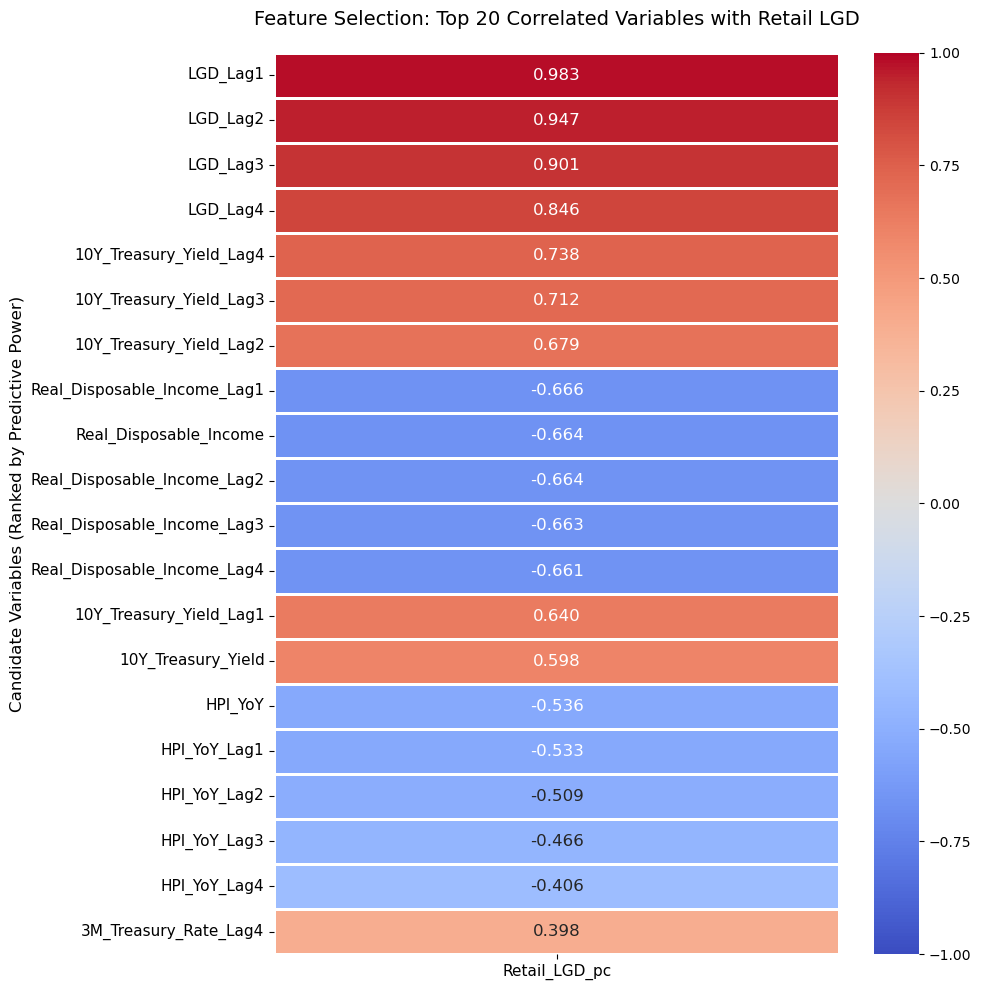

In [52]:
plt.figure(figsize=(10, 10))

target = 'Retail_LGD_pc'

corr_with_lgd = df_model.corr()[[target]].drop(target)
corr_with_lgd['Absolute_Corr'] = corr_with_lgd[target].abs()
corr_with_lgd_sorted = corr_with_lgd.sort_values(by='Absolute_Corr', ascending=False)
corr_with_lgd_sorted.drop(columns=['Absolute_Corr'], inplace=True)

top_20_features = corr_with_lgd_sorted.head(20)

sns.heatmap(top_20_features, annot=True, annot_kws={"size": 12}, 
            cmap='coolwarm', fmt=".3f", linewidths=1, vmin=-1, vmax=1)

plt.title('Feature Selection: Top 20 Correlated Variables with Retail LGD', fontsize=14, pad=20)
plt.ylabel('Candidate Variables (Ranked by Predictive Power)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('./output/chart_lgd_retail_feature_selection.png', dpi=600, bbox_inches='tight')
plt.show()

In [59]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

In [54]:
# 1. Setup variables
target = 'Retail_LGD_pc'
# Exclude the target itself from potential features
candidate_features = [col for col in df_model.columns if col != target]

# 2. Step 1: Correlation Screening (|r| > 0.5)
correlations = df_model.corr()[target].drop(target)
high_corr_features = correlations[correlations.abs() > 0.5].abs().sort_values(ascending=False).index.tolist()

print(f"Features passing initial correlation screen: {high_corr_features}")

Features passing initial correlation screen: ['LGD_Lag1', 'LGD_Lag2', 'LGD_Lag3', 'LGD_Lag4', '10Y_Treasury_Yield_Lag4', '10Y_Treasury_Yield_Lag3', '10Y_Treasury_Yield_Lag2', 'Real_Disposable_Income_Lag1', 'Real_Disposable_Income', 'Real_Disposable_Income_Lag2', 'Real_Disposable_Income_Lag3', 'Real_Disposable_Income_Lag4', '10Y_Treasury_Yield_Lag1', '10Y_Treasury_Yield', 'HPI_YoY', 'HPI_YoY_Lag1', 'HPI_YoY_Lag2']


In [55]:
# 3. Step 2: Remove Redundant Variables (Inter-correlation > 0.85)
# We keep the one with the higher correlation to the target (already sorted)
final_candidates = []
for feat in high_corr_features:
    is_redundant = False
    for selected in final_candidates:
        if abs(df_model[feat].corr(df_model[selected])) > 0.85:
            is_redundant = True
            break
    if not is_redundant:
        final_candidates.append(feat)

print(f"Features after redundancy check: {final_candidates}")

Features after redundancy check: ['LGD_Lag1', '10Y_Treasury_Yield_Lag4', 'Real_Disposable_Income_Lag1', '10Y_Treasury_Yield', 'HPI_YoY']


In [56]:
# 4. Step 3: Backward Elimination (p-value < 0.05)
def backward_elimination(df, target_var, features):
    current_features = list(features)
    while len(current_features) > 0:
        X = sm.add_constant(df[current_features])
        model = sm.OLS(df[target_var], X).fit()
        # Get p-values for features (excluding constant)
        p_values = model.pvalues.drop('const')
        max_p = p_values.max()
        
        if max_p > 0.05:
            excluded_feature = p_values.idxmax()
            print(f"Removing {excluded_feature} (p-value: {max_p:.4f})")
            current_features.remove(excluded_feature)
        else:
            break
    return current_features, model

selected_features, final_model = backward_elimination(df_model, target, final_candidates)

Removing 10Y_Treasury_Yield_Lag4 (p-value: 0.8896)
Removing Real_Disposable_Income_Lag1 (p-value: 0.2312)


In [57]:
print("\n--- Final Selected Features ---")
print(selected_features)
print("\n--- Final Model Summary ---")
print(final_model.summary())


--- Final Selected Features ---
['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY']

--- Final Model Summary ---
                            OLS Regression Results                            
Dep. Variable:          Retail_LGD_pc   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     1064.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           2.20e-72
Time:                        02:39:32   Log-Likelihood:                 475.18
No. Observations:                  98   AIC:                            -942.4
Df Residuals:                      94   BIC:                            -932.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------

In [60]:
# 5. Step 4: Cross-Validation (13-Quarter Test Window)
tscv = TimeSeriesSplit(n_splits=5, test_size=13)
cv_scores = []

for train_idx, test_idx in tscv.split(df_model):
    X_train, X_test = df_model[selected_features].iloc[train_idx], df_model[selected_features].iloc[test_idx]
    y_train, y_test = df_model[target].iloc[train_idx], df_model[target].iloc[test_idx]
    
    # Fit on training fold
    fold_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
    
    # Predict on test fold
    y_pred = fold_model.predict(sm.add_constant(X_test))
    cv_scores.append(r2_score(y_test, y_pred))

print(f"\nAverage 13-Quarter Test R-squared: {np.mean(cv_scores):.4f}")


Average 13-Quarter Test R-squared: 0.6881


In [61]:
print(f"\nAverage 13-Quarter Test R-squared: {np.mean(cv_scores):.4f}")

# 6. Step 5: Check Multicollinearity (VIF)
X_vif = sm.add_constant(df_model[selected_features])
vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
})
print("\n--- Variance Inflation Factors ---")
print(vif_data)


Average 13-Quarter Test R-squared: 0.6881

--- Variance Inflation Factors ---
              Feature        VIF
0               const  14.464576
1            LGD_Lag1   2.260709
2  10Y_Treasury_Yield   1.669902
3             HPI_YoY   1.533587


In [62]:


# 1. Setup target and candidate feature sets
# Assuming df_model is already loaded in your environment
target = 'Retail_LGD_pc'

model_specs = {
    "Model A (Base)": ['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY'],
    "Model B (+ Unemployment)": ['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY', 'Unemployment_Rate'],
    "Model C (+ Unempl Lag1)": ['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY', 'Unemployment_Rate_Lag1'],
    "Model D (+ Unempl Lag3)": ['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY', 'Unemployment_Rate_Lag3']
}

# 2. Define the Cross-Validation Function (13-quarter test window)
def evaluate_model_cv(df, features, target_col, n_splits=5, test_size=13):
    X = df[features]
    y = df[target_col]
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    cv_metrics = []
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Fit OLS with constant
        X_train_c = sm.add_constant(X_train)
        X_test_c = sm.add_constant(X_test)
        model = sm.OLS(y_train, X_train_c).fit()
        
        # Predict
        y_train_pred = model.predict(X_train_c)
        y_test_pred = model.predict(X_test_c)
        
        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)
        
        cv_metrics.append({
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'test_r2': test_r2
        })
    
    cv_df = pd.DataFrame(cv_metrics)
    
    # Calculate In-Sample stats for the full dataset
    X_full = sm.add_constant(X)
    full_model = sm.OLS(y, X_full).fit()
    
    return {
        'Avg Test RMSE': cv_df['test_rmse'].mean(),
        'Avg Test R2': cv_df['test_r2'].mean(),
        'Avg Train RMSE': cv_df['train_rmse'].mean(),
        'Overfit Gap (RMSE)': cv_df['test_rmse'].mean() - cv_df['train_rmse'].mean(),
        'Adj R2': full_model.rsquared_adj,
        'AIC': full_model.aic,
        'BIC': full_model.bic
    }

# 3. Execute Model Comparison
results = {}
for name, feats in model_specs.items():
    results[name] = evaluate_model_cv(df_model, feats, target)

comparison_df = pd.DataFrame(results).T
print("--- Model Comparison: CV & In-Sample Results ---")
print(comparison_df[['Avg Test RMSE', 'Avg Test R2', 'Overfit Gap (RMSE)', 'Adj R2', 'AIC']])

# 4. Multicollinearity Check (VIF) for the model including Unemployment
X_vif = sm.add_constant(df_model[model_specs["Model B (+ Unemployment)"]])
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- Variance Inflation Factors (Model B) ---")
print(vif_df)

# 5. Residual Analysis for the Base Model (To find hidden patterns)
X_base = sm.add_constant(df_model[model_specs["Model A (Base)"]])
base_model = sm.OLS(df_model[target], X_base).fit()
df_model['residuals'] = base_model.resid

# Check correlations of other variables with the residuals
resid_correlations = df_model.corr()['residuals'].abs().sort_values(ascending=False)
print("\n--- Correlation of Residuals with Macro Candidates ---")
print(resid_correlations.head(10))

--- Model Comparison: CV & In-Sample Results ---
                          Avg Test RMSE  Avg Test R2  Overfit Gap (RMSE)  \
Model A (Base)                 0.002200     0.688064            0.000056   
Model B (+ Unemployment)       0.003388     0.030393            0.001441   
Model C (+ Unempl Lag1)        0.003269    -0.206056            0.001393   
Model D (+ Unempl Lag3)        0.002618    -0.655186            0.000823   

                            Adj R2         AIC  
Model A (Base)            0.970477 -942.365712  
Model B (+ Unemployment)  0.974008 -953.896621  
Model C (+ Unempl Lag1)   0.975584 -960.026978  
Model D (+ Unempl Lag3)   0.975062 -957.954105  

--- Variance Inflation Factors (Model B) ---
              Feature        VIF
0               const  32.861224
1            LGD_Lag1   4.660360
2  10Y_Treasury_Yield   3.433693
3             HPI_YoY   1.538638
4   Unemployment_Rate   2.725101

--- Correlation of Residuals with Macro Candidates ---
residuals                

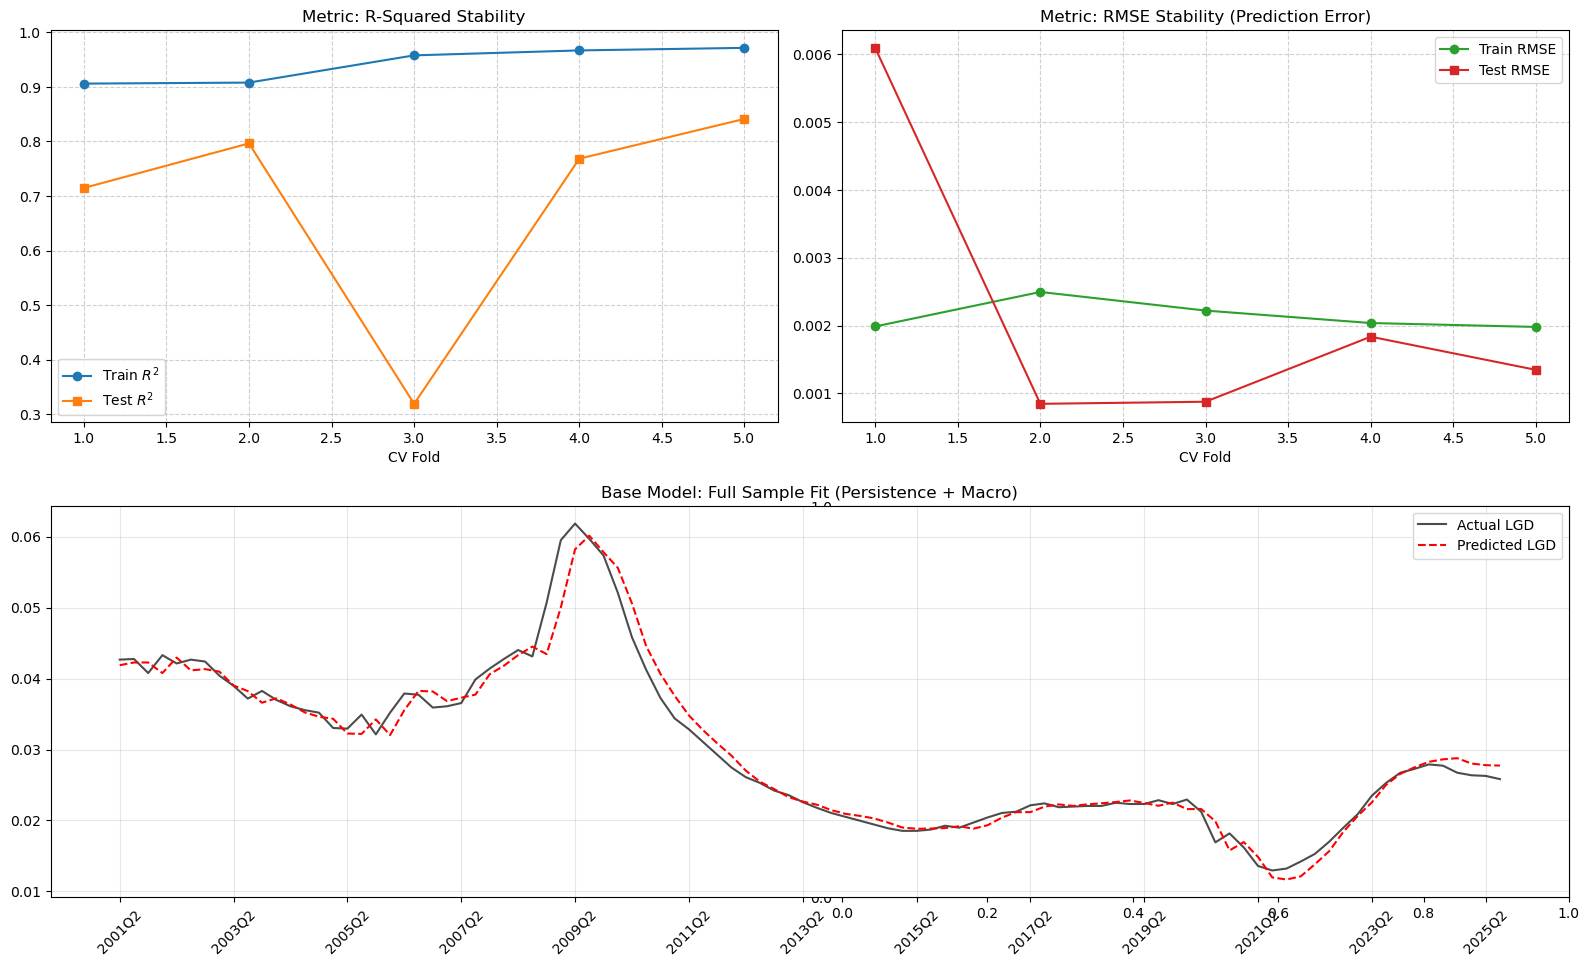

--- Average 13-Quarter Validation Results ---
Train R2      0.942125
Test R2       0.688064
Train RMSE    0.002144
Test RMSE     0.002200
dtype: float64


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# 1. Setup Variables
# Assuming df_model is your primary DataFrame
target = 'Retail_LGD_pc'
features = ['LGD_Lag1', '10Y_Treasury_Yield', 'HPI_YoY']

X = df_model[features]
y = df_model[target]

# 2. Time Series Cross-Validation (5 Folds, 13-Quarter Test Size)
tscv = TimeSeriesSplit(n_splits=5, test_size=13)
cv_results = []

# Prepare for visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit model on training data
    X_train_const = sm.add_constant(X_train)
    model = sm.OLS(y_train, X_train_const).fit()
    
    # Predict both sets
    y_train_pred = model.predict(X_train_const)
    y_test_pred = model.predict(sm.add_constant(X_test))
    
    # Metrics
    cv_results.append({
        'Fold': i + 1,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
    })

results_df = pd.DataFrame(cv_results)

# 3. Visual: Performance Metrics across Folds
# Plot R-squared
axes[0].plot(results_df['Fold'], results_df['Train R2'], marker='o', label='Train $R^2$', color='#1f77b4')
axes[0].plot(results_df['Fold'], results_df['Test R2'], marker='s', label='Test $R^2$', color='#ff7f0e')
axes[0].set_title('Metric: R-Squared Stability')
axes[0].set_xlabel('CV Fold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot RMSE
axes[1].plot(results_df['Fold'], results_df['Train RMSE'], marker='o', label='Train RMSE', color='#2ca02c')
axes[1].plot(results_df['Fold'], results_df['Test RMSE'], marker='s', label='Test RMSE', color='#d62728')
axes[1].set_title('Metric: RMSE Stability (Prediction Error)')
axes[1].set_xlabel('CV Fold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# 4. Visual: Final Actual vs. Predicted (Full Dataset)
full_model = sm.OLS(y, sm.add_constant(X)).fit()
y_pred_full = full_model.predict(sm.add_constant(X))

axes[2].set_axis_off() # Use bottom row for full-width plot
ax_full = fig.add_subplot(2, 1, 2)
# Convert Period index to string for plotting
index_labels = df_model.index.astype(str)
ax_full.plot(range(len(index_labels)), y, label='Actual LGD', color='black', linewidth=1.5, alpha=0.7)
ax_full.plot(range(len(index_labels)), y_pred_full, label='Predicted LGD', color='red', linestyle='--', linewidth=1.5)
ax_full.set_title('Base Model: Full Sample Fit (Persistence + Macro)')
ax_full.set_xticks(range(0, len(index_labels), 8))
ax_full.set_xticklabels(index_labels[::8], rotation=45)
ax_full.legend()
ax_full.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print average stats
print("--- Average 13-Quarter Validation Results ---")
print(results_df[['Train R2', 'Test R2', 'Train RMSE', 'Test RMSE']].mean())